# Supermarket Analysis Project
**Author:** Ripan Nurpaujan | **Date:** Dec 2025

In [3]:
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

# List kosong untuk menampung "arwah" gambar-gambar kita
list_gambar = []

## 1. Data Pre-processing
- **Load Data:** Import `pandas`, `seaborn`. Read csv.
- **Health Check:** `df.info()`, `df.describe()`, `df.isnull().sum()`.
- **Cleaning:** Convert `to_datetime`, handle missing values.

In [4]:
import pandas as pd

# load data
df = pd.read_csv("supermarket_sales - Sheet1.csv")
df.head(10)

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3
5,699-14-3026,C,Naypyitaw,Normal,Male,Electronic accessories,85.39,7,29.8865,627.6165,3/25/2019,18:30,Ewallet,597.73,4.761905,29.8865,4.1
6,355-53-5943,A,Yangon,Member,Female,Electronic accessories,68.84,6,20.6520,433.6920,2/25/2019,14:36,Ewallet,413.04,4.761905,20.6520,5.8
7,315-22-5665,C,Naypyitaw,Normal,Female,Home and lifestyle,73.56,10,36.7800,772.3800,2/24/2019,11:38,Ewallet,735.60,4.761905,36.7800,8.0
8,665-32-9167,A,Yangon,Member,Female,Health and beauty,36.26,2,3.6260,76.1460,1/10/2019,17:15,Credit card,72.52,4.761905,3.6260,7.2
9,692-92-5582,B,Mandalay,Member,Female,Food and beverages,54.84,3,8.2260,172.7460,2/20/2019,13:27,Credit card,164.52,4.761905,8.2260,5.9


In [5]:
# Check data information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Total                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

In [6]:
# convert date column into datetime format
df['Date'] = pd.to_datetime(df['Date'])
df['Date'].head(10)

0   2019-01-05
1   2019-03-08
2   2019-03-03
3   2019-01-27
4   2019-02-08
5   2019-03-25
6   2019-02-25
7   2019-02-24
8   2019-01-10
9   2019-02-20
Name: Date, dtype: datetime64[ns]

In [7]:
# set date column as index
df.set_index('Date', inplace=True)
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Time,Payment,cogs,gross margin percentage,gross income,Rating
Date,,,,,,,,,,,,,,,,
2019-01-05,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,13:08,Ewallet,522.83,4.761905,26.1415,9.1
2019-03-08,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,10:29,Cash,76.40,4.761905,3.8200,9.6
2019-03-03,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,13:23,Credit card,324.31,4.761905,16.2155,7.4
2019-01-27,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,20:33,Ewallet,465.76,4.761905,23.2880,8.4
2019-02-08,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,10:37,Ewallet,604.17,4.761905,30.2085,5.3


In [8]:
# statistic
df.describe()

,Unit price,Quantity,Tax 5%,Total,cogs,gross margin percentage,gross income,Rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.00000
mean,55.672130,5.510000,15.379369,322.966749,307.58738,4.761905,15.379369,6.97270
std,26.494628,2.923431,11.708825,245.885335,234.17651,0.000000,11.708825,1.71858
min,10.080000,1.000000,0.508500,10.678500,10.17000,4.761905,0.508500,4.00000
25%,32.875000,3.000000,5.924875,124.422375,118.49750,4.761905,5.924875,5.50000
50%,55.230000,5.000000,12.088000,253.848000,241.76000,4.761905,12.088000,7.00000
75%,77.935000,8.000000,22.445250,471.350250,448.90500,4.761905,22.445250,8.50000
max,99.960000,10.000000,49.650000,1042.650000,993.00000,4.761905,49.650000,10.00000


## 2. Exploratory Data Analysis (EDA)
- **Univariate:** `sns.histplot` (Numerical), `sns.countplot` (Categorical).
- **Bivariate:** `sns.boxplot` (Correlations).
- **Time Series:** `df.resample().plot()` (Trends over time).

In [9]:
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Time,Payment,cogs,gross margin percentage,gross income,Rating
Date,,,,,,,,,,,,,,,,
2019-01-05,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,13:08,Ewallet,522.83,4.761905,26.1415,9.1
2019-03-08,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,10:29,Cash,76.40,4.761905,3.8200,9.6
2019-03-03,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,13:23,Credit card,324.31,4.761905,16.2155,7.4
2019-01-27,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,20:33,Ewallet,465.76,4.761905,23.2880,8.4
2019-02-08,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,10:37,Ewallet,604.17,4.761905,30.2085,5.3


### 2.1     Univariate

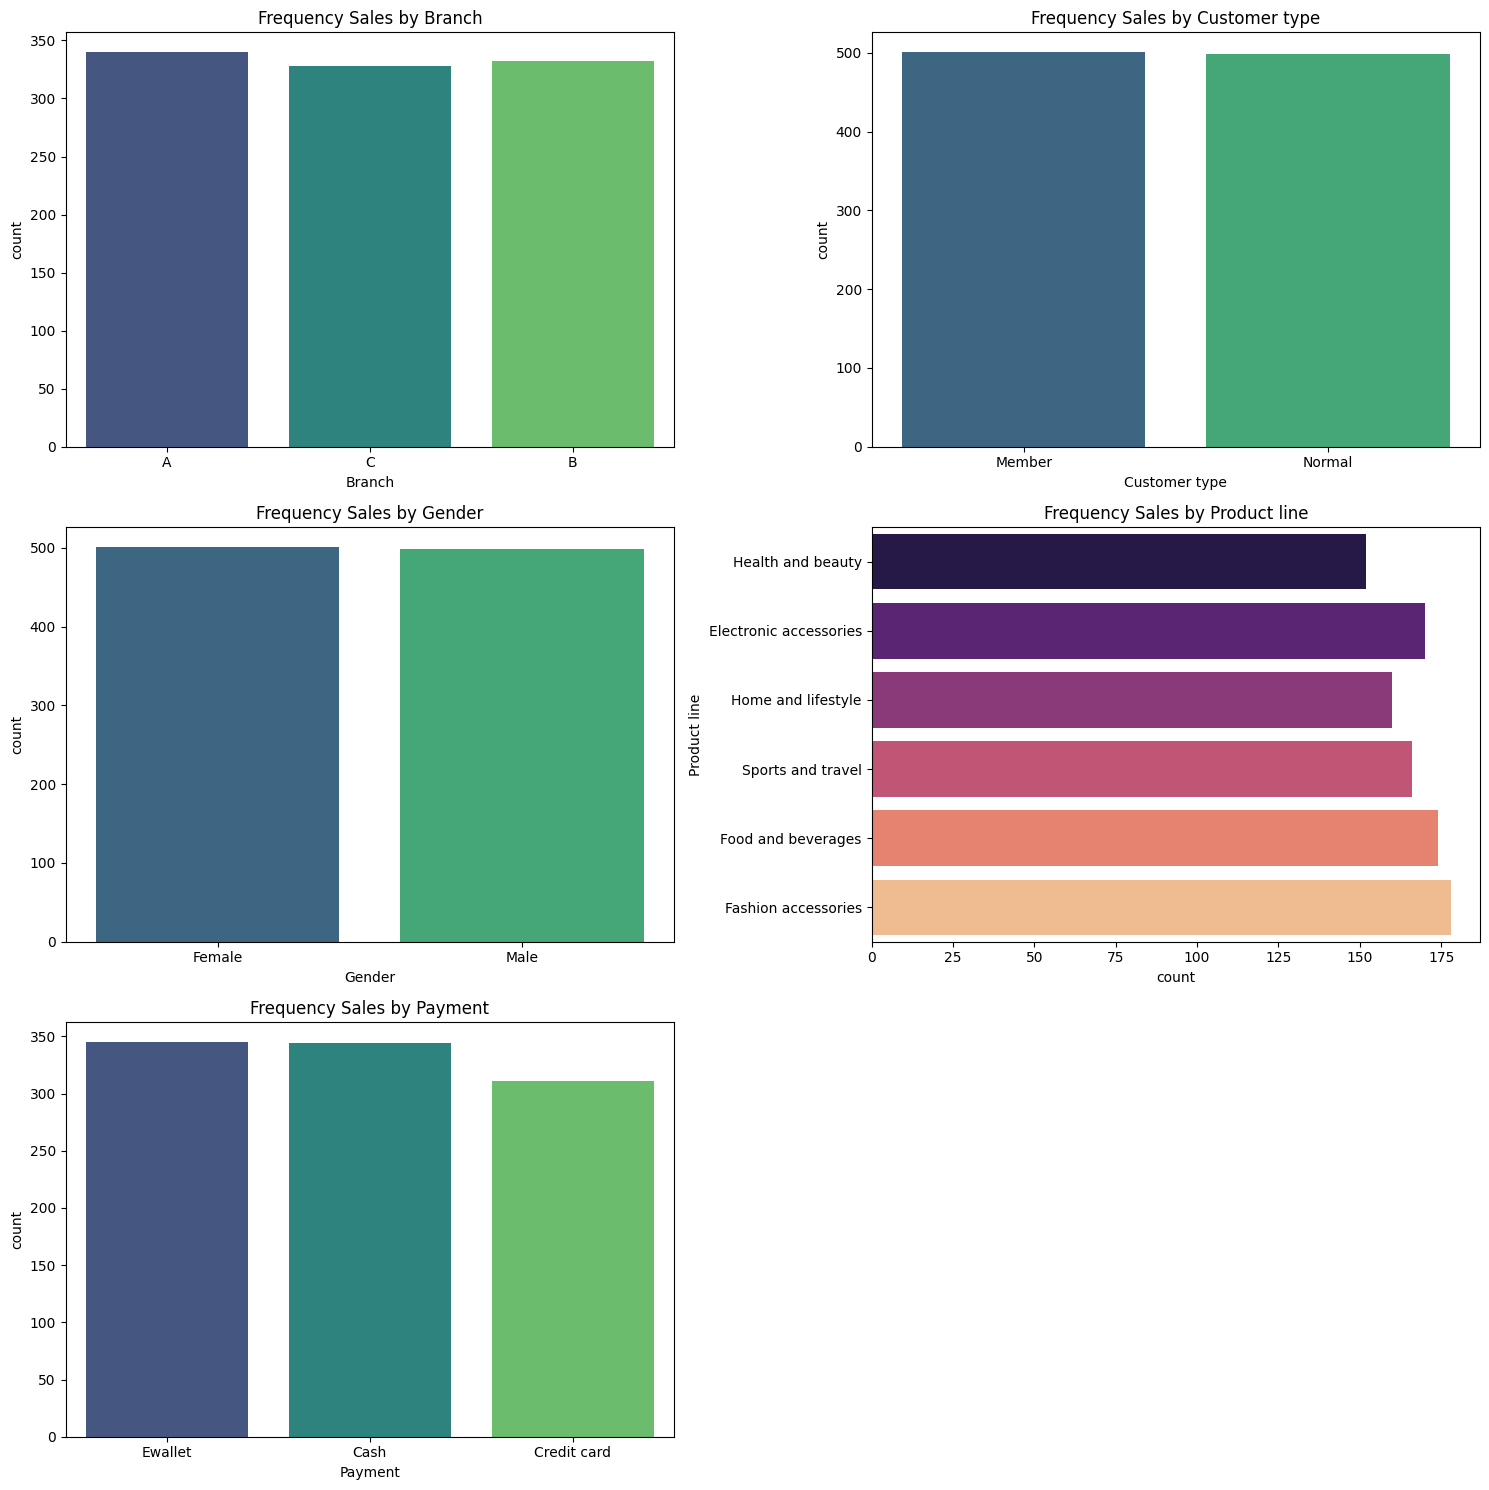

In [10]:
import seaborn as sns 
import matplotlib.pyplot as plt

# list of features
features = ['Branch', 'Customer type', 'Gender', 'Product line', 'Payment']

# setup canvas
fig, ax = plt.subplots(3, 2, figsize=(15, 15))

# graphic frequency of sales by feature 
axes = ax.flatten()

for i, col in enumerate(features):
    if col == 'Product line':
        sns.countplot(y=col, data=df, ax=axes[i], palette='magma', hue=col, legend=False)
    else:
        sns.countplot(x=col, data=df, ax=axes[i], palette='viridis', hue=col, legend=False)
    
    axes[i].set_title(f'Frequency Sales by {col}')


fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

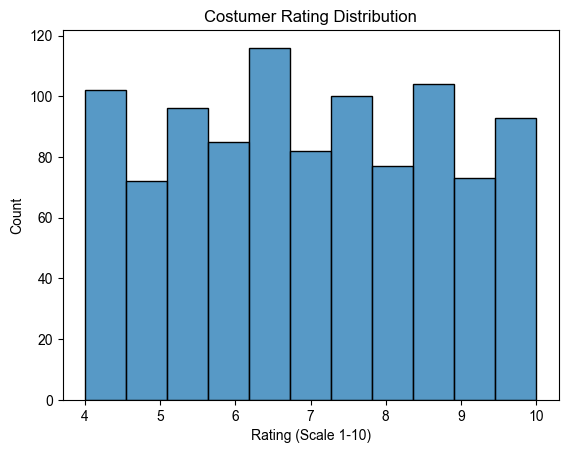

In [11]:
# costumer rating distribution
sns.histplot(x='Rating', data=df)
sns.set_style("whitegrid")
plt.title('Costumer Rating Distribution')
plt.xlabel('Rating (Scale 1-10)')
plt.show()

### 2.2 Bivariate (Correlations)

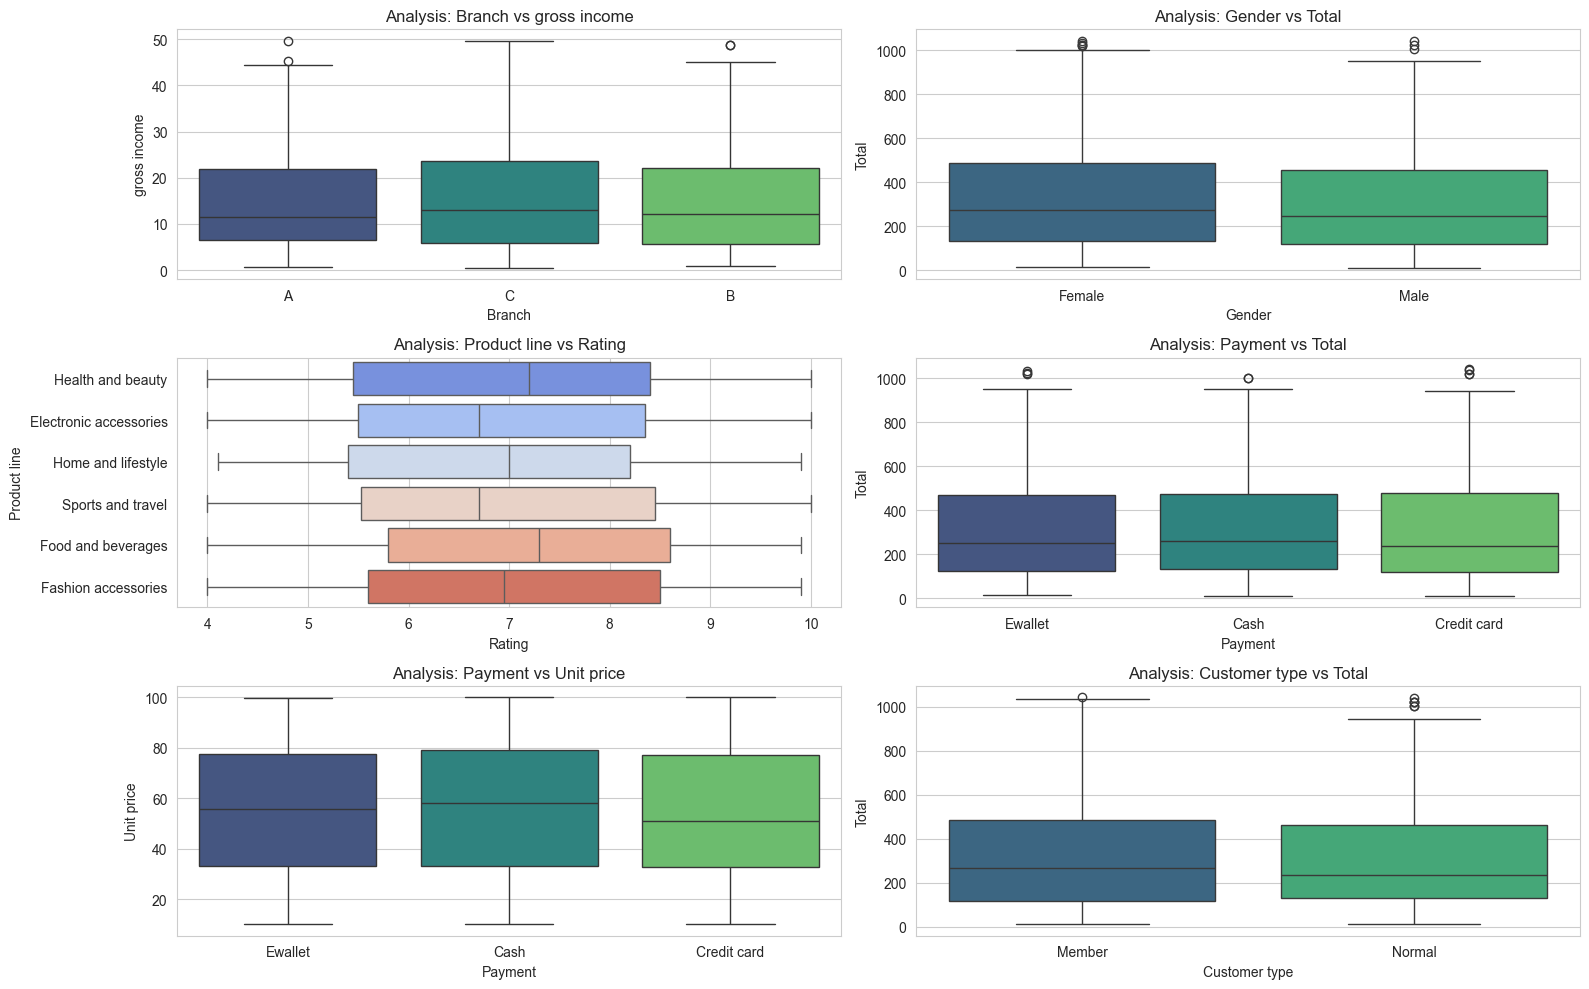

In [12]:
# CATEGORICAL DATA
# define x and y variable (one categorical variable and othe variable is numerical)
x_var = ['Branch', 'Gender', 'Product line', 'Payment', 'Payment', 'Customer type']
y_var = ['gross income','Total','Rating', 'Total', 'Unit price',  'Total']

# setup canvas
fig, ax = plt.subplots(3, 2, figsize=(16,10))
axes = ax.flatten()

# graphic each x feature using zip
for i, (x_col, y_col) in enumerate(zip(x_var, y_var)):
    if x_col == 'Product line':
        sns.boxplot(
        data=df,
        x = y_col,
        y = x_col,
        ax = axes[i],
        palette='coolwarm',
        hue=x_col,
        legend=False
    )
    else:
        sns.boxplot(
            data=df,
            x = x_col,
            y = y_col,
            ax = axes[i],
            palette='viridis',
            hue=x_col,
            legend=False
        )
    axes[i].set_title(f'Analysis: {x_col} vs {y_col}')

plt.tight_layout()
plt.show()


In [22]:
# Aggregation: Membandingkan Rata-rata Belanja (Spending Power) & Kebiasaan (Basket Size)
customer_comparison = df.groupby('Customer type').agg({
    'Total': 'mean',      # Rata-rata Uang yang dikeluarkan per struk ($)
    'Quantity': 'mean',   # Rata-rata Jumlah barang per struk (Items)
    'gross income': 'mean' # Rata-rata Keuntungan per struk ($)
}).round(2) # Bulatkan 2 angka desimal biar rapi

# Rename kolom biar bahasa manusia (Presentasi Friendly)
customer_comparison.columns = ['Avg Spending ($)', 'Avg Basket Size (Qty)', 'Avg Profit ($)']

print("--- Tabel Perbandingan Member vs Normal ---")
print(customer_comparison)

--- Tabel Perbandingan Member vs Normal ---
               Avg Spending ($)  Avg Basket Size (Qty)  Avg Profit ($)
Customer type                                                         
Member                   327.79                   5.56           15.61
Normal                   318.12                   5.46           15.15


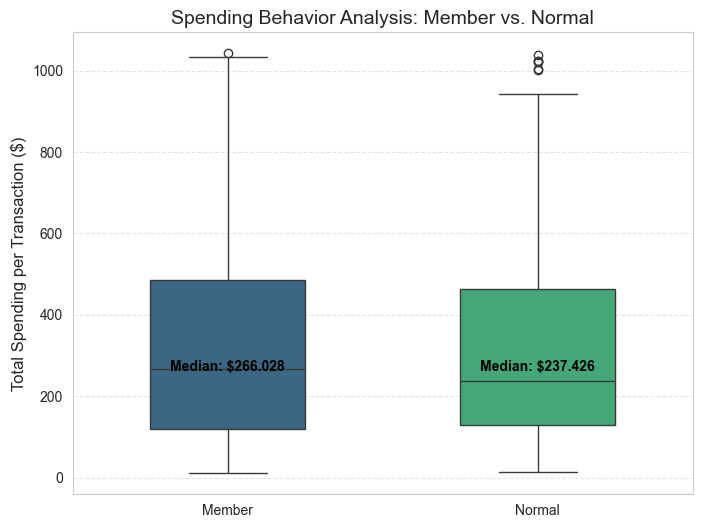

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

# Boxplot: Membandingkan Distribusi Belanja
sns.boxplot(
    data=df, 
    x='Customer type', 
    y='Total', 
    palette='viridis', # Warna senada dengan Pie Chart tadi
    hue='Customer type',
    width=0.5 # Biar kotaknya langsing, elegan
)

# Styling biar profesional
plt.title('Spending Behavior Analysis: Member vs. Normal', fontsize=14)
plt.ylabel('Total Spending per Transaction ($)', fontsize=12)
plt.xlabel('') # Hilangkan label X karena sudah jelas dari teks barnya
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Trik Psikologis: Tambahkan teks di dalam plot
# (Ganti koordinat y sesuai datamu, misal di tengah-tengah)
plt.text(0, df['Total'].median(), f"Median: ${df[df['Customer type']=='Member']['Total'].median()}", 
         ha='center', va='bottom', color='black', fontweight='bold')
plt.text(1, df['Total'].median(), f"Median: ${df[df['Customer type']=='Normal']['Total'].median()}", 
         ha='center', va='bottom', color='black', fontweight='bold')

# Save
# export("Slide6_Boxplot_Analysis.png")
plt.show()

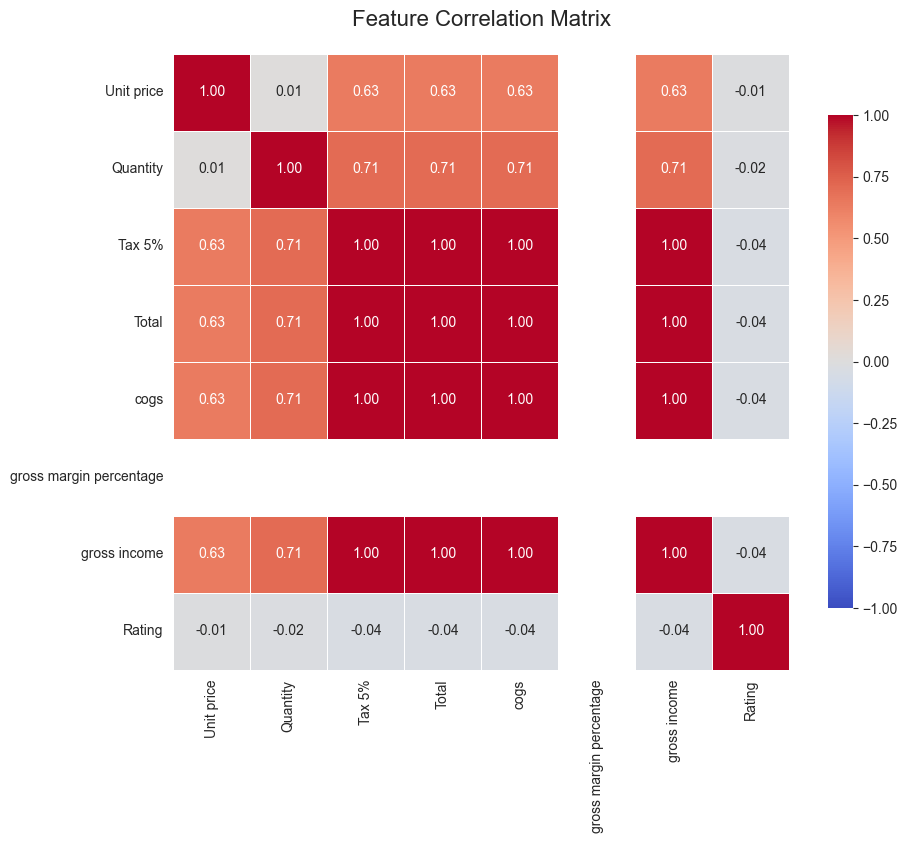

In [13]:
# NUMERICAL DATA
# 1. Data Selection: Filter numerical columns
numerical_df = df.select_dtypes(include=['float64', 'int64'])

# 2. Compute Correlation Matrix
corr_matrix = numerical_df.corr()

# 3. Visualization 
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,         
    cmap='coolwarm',    
    fmt=".2f",          
    linewidths=0.5,     
    vmin=-1, vmax=1,    
    square=True,        
    cbar_kws={"shrink": .8} 
)

plt.title('Feature Correlation Matrix', fontsize=16, pad=20)
plt.yticks(rotation=0)  
plt.show()

### 2.3 Temporal Analysis

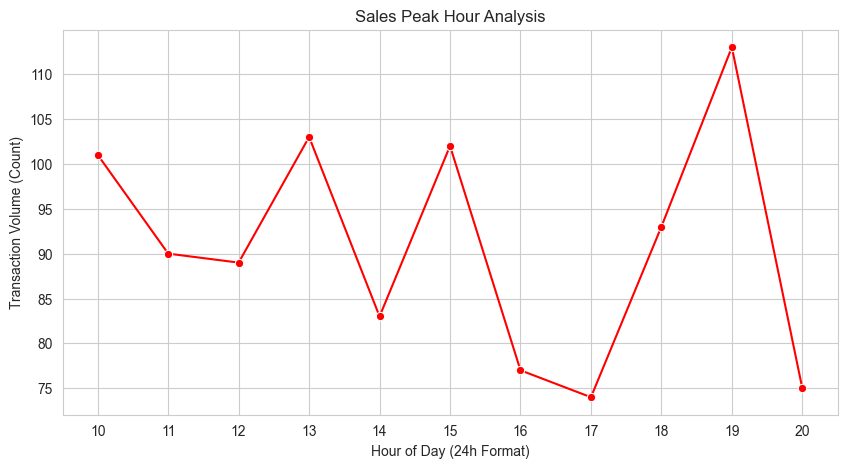

In [14]:
# SALES PEAK HOUR ANALYSIS
# feature engineering: extract the 'Hour' from the 'Time' column
df['Hour'] = pd.to_datetime(df['Time'], format='%H:%M').dt.hour

# data preparation 
hourly_sales = df['Hour'].value_counts().sort_index()

# visualization
plt.figure(figsize=(10, 5))
sns.lineplot(
    x=hourly_sales.index,
    y=hourly_sales.values,
    marker='o',
    color='red'
)

# chart styling (labels & titles)
plt.title('Sales Peak Hour Analysis') 
plt.xlabel('Hour of Day (24h Format)') 
plt.ylabel('Transaction Volume (Count)')    
plt.grid(True)                              
plt.xticks(range(10, 21))                   

plt.show()

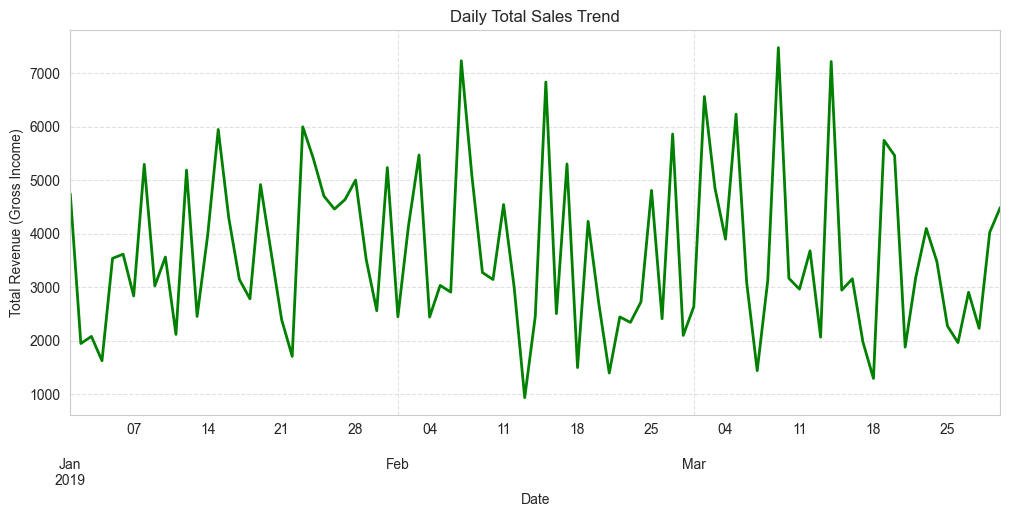

In [15]:
# DAILY TOTAL SALES TREND
# data preparation: using resample 
daily_trend = df['Total'].resample('D').sum()

# Visualization
plt.figure(figsize=(12, 5))

daily_trend.plot(color='green', linewidth=2)

plt.title('Daily Total Sales Trend')        
plt.xlabel('Date')                          
plt.ylabel('Total Revenue (Gross Income)')  
plt.grid(True, linestyle='--', alpha=0.6)   
plt.show()

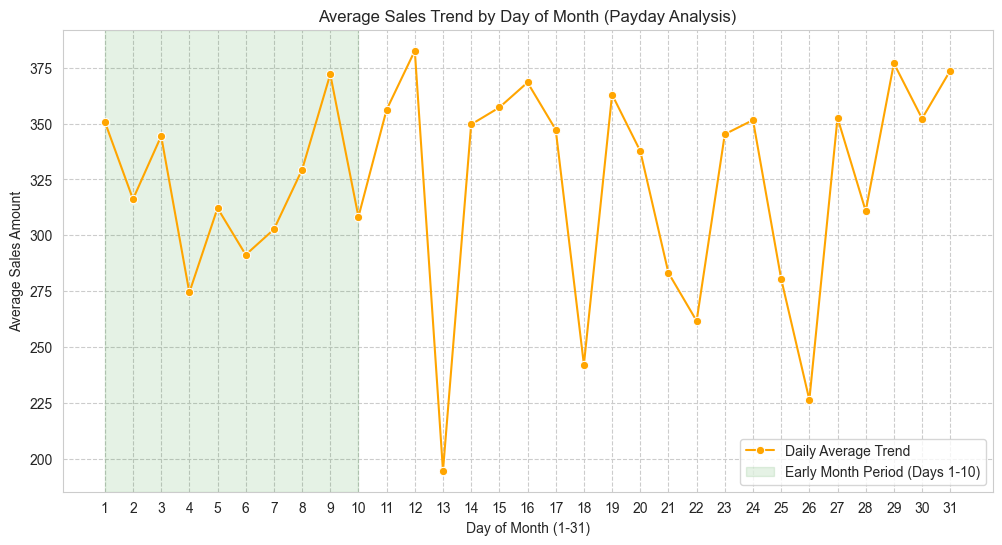

In [16]:
# AVERAGE SALES TREND BY DAY OF MONTH (PAYDAY ANALYSIS)
# feature engineering: extract day number
day_sales = df.groupby(df.index.day)['Total'].mean()

plt.figure(figsize=(12,6))

# visualization 
sns.lineplot(
    x=day_sales.index,
    y=day_sales.values,
    marker='o',
    color='orange',
    label='Daily Average Trend'
)

# analytic highlight: the 'early month' zone
plt.axvspan(1, 10, color='green', alpha=0.1, label='Early Month Period (Days 1-10)')

# Chart Styling
plt.title('Average Sales Trend by Day of Month (Payday Analysis)')
plt.xlabel('Day of Month (1-31)')
plt.ylabel('Average Sales Amount')
plt.xticks(range(1, 32))
plt.grid(True, linestyle='--')
plt.legend()
plt.show()


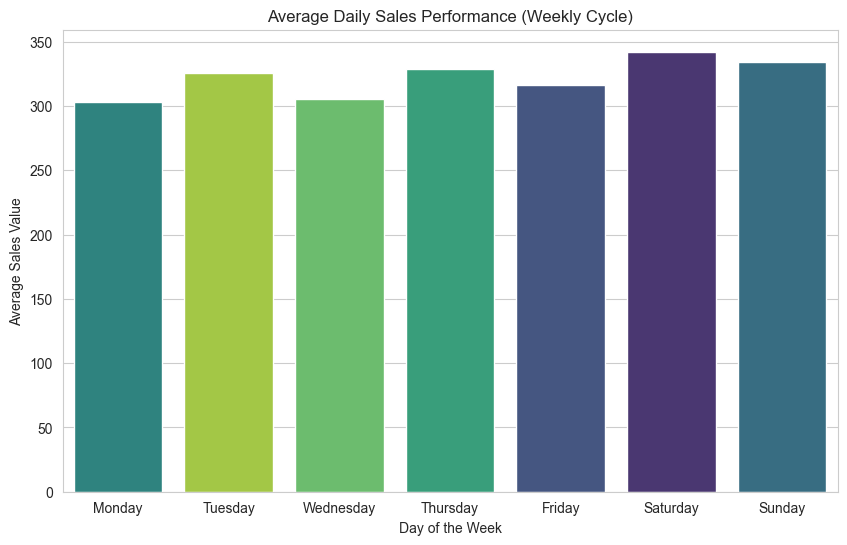

In [17]:
# AVERAGE DAILY SALES PERFORMANCE (WEEKLY CYCLE)
# feature engineering: extract Day Names
df['Day_Name'] = df.index.day_name()

# define day name
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

plt.figure(figsize=(10, 6))

# visualization 
sns.barplot(
    data=df,
    x='Day_Name',
    y='Total',
    order=day_order,
    palette='viridis',
    hue='Day_Name',
    legend=False,
    errorbar=None
)

plt.title('Average Daily Sales Performance (Weekly Cycle)')
plt.xlabel('Day of the Week')
plt.ylabel('Average Sales Value')
plt.show()

### 2.4 Product Performance

--- Product Line Summary ---
                        Quantity  gross income    Rating
Product line                                            
Food and beverages           952     2673.5640  7.113218
Sports and travel            920     2624.8965  6.916265
Electronic accessories       971     2587.5015  6.924706
Fashion accessories          902     2585.9950  7.029213
Home and lifestyle           911     2564.8530  6.837500
Health and beauty            854     2342.5590  7.003289


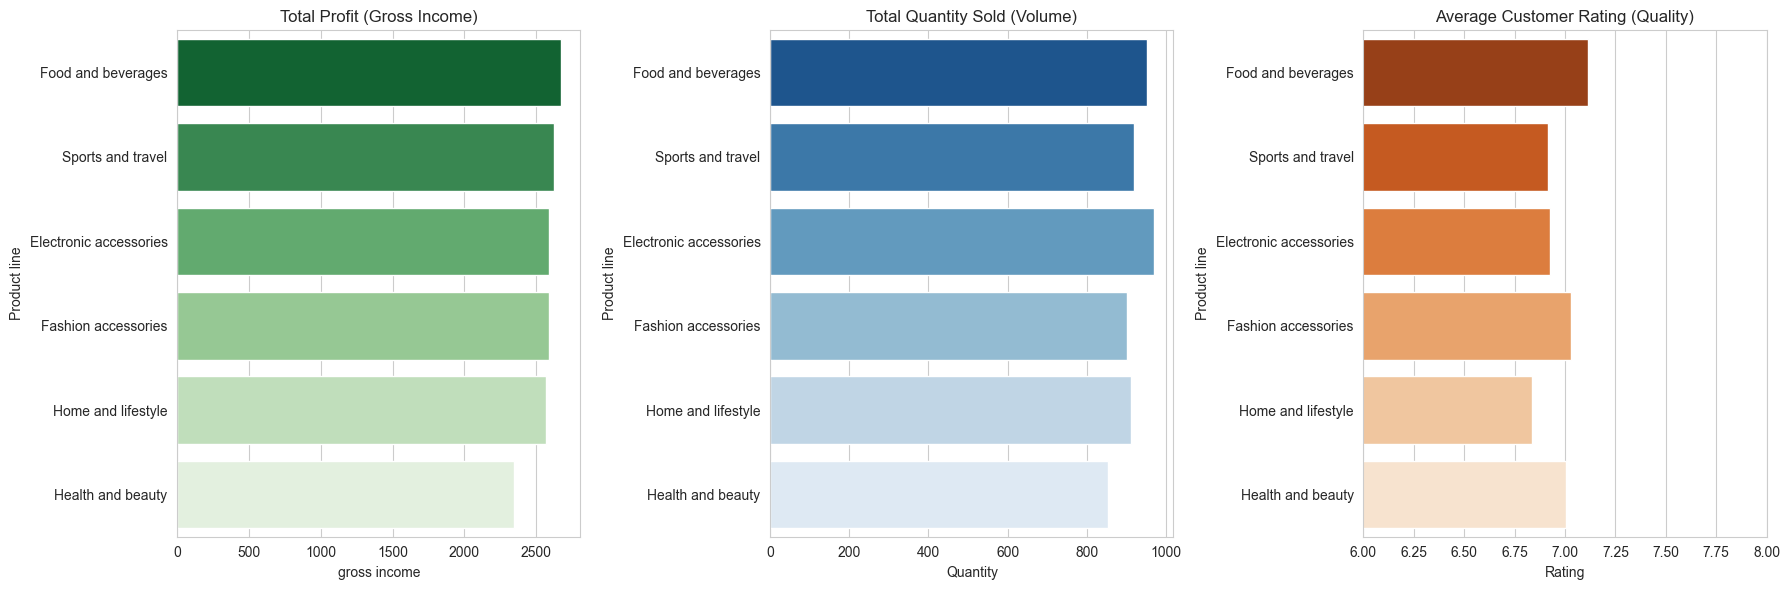

In [18]:
# data aggregation: product performance matrix
product_summary = df.groupby('Product line').agg({
    'Quantity': 'sum',
    'gross income':'sum',
    'Rating':'mean'
}).sort_values('gross income', ascending=False)

print('--- Product Line Summary ---')
print(product_summary)

# comparative visualization 
fig, ax = plt.subplots(1, 3, figsize=(18,6))

metrics = ['gross income', 'Quantity', 'Rating']
palettes = ['Greens_r', 'Blues_r', 'Oranges_r']
titles = [
    'Total Profit (Gross Income)', 
    'Total Quantity Sold (Volume)', 
    'Average Customer Rating (Quality)'
]

axes = ax.flatten()

for i, (col, color, title) in enumerate(zip(metrics, palettes, titles)):
    # plotting
    sns.barplot(
        y=product_summary.index, 
        x=product_summary[col],
        ax = axes[i],
        palette=color,
        hue=product_summary.index,
        legend=False
    )

    # styling
    axes[i].set_title(title)
    
    # special condition
    if col == 'Rating':
        axes[i].set_xlim(6,8)


plt.tight_layout() 
plt.show()

--- Average Unit Price Analysis (Premium vs Economy) ---
Product line
Fashion accessories       57.153652
Sports and travel         56.993253
Food and beverages        56.008851
Home and lifestyle        55.316937
Health and beauty         54.854474
Electronic accessories    53.551588
Name: Unit price, dtype: float64


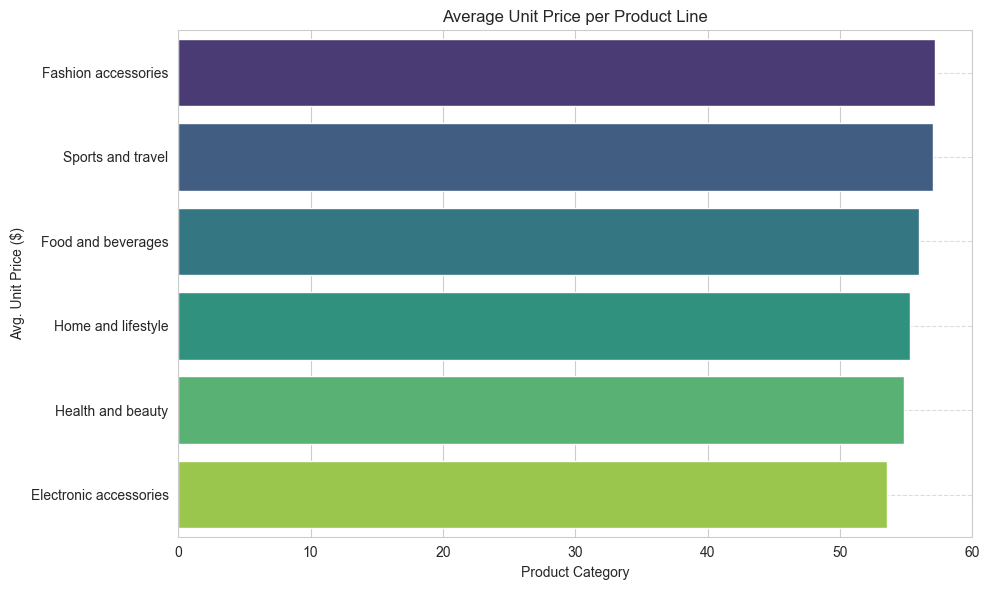

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Data Aggregation: Calculate Average Unit Price
# We group by product line to see which category sells the most expensive items on average.
avg_unit_price = df.groupby('Product line')['Unit price'].mean().sort_values(ascending=False)

print("--- Average Unit Price Analysis (Premium vs Economy) ---")
print(avg_unit_price)

# 2. Visualization
plt.figure(figsize=(10, 6))

# Barplot to compare the "Value" of each category
sns.barplot(
    y=avg_unit_price.index, 
    x=avg_unit_price.values, 
    palette='viridis', 
    hue=avg_unit_price.index, 
    legend=False
)

# 3. Chart Styling
plt.title('Average Unit Price per Product Line')
plt.xlabel('Product Category')
plt.ylabel('Avg. Unit Price ($)') # Always include units!
plt.grid(axis='y', linestyle='--', alpha=0.7) # Add grid lines for easier reading

plt.tight_layout()
plt.show()

## 3. Advanced Insight
- **Feature Engineering:** Create new metrics (e.g., Profit per Unit).
- **Anomaly Detection:** Identify underperforming high-volume products.

--- Gross Profit Analysis (Profit per Unit) ---
                        gross income  Quantity  Profit_per_Unit
Product line                                                   
Fashion accessories        2585.9950       902         2.866957
Sports and travel          2624.8965       920         2.853148
Home and lifestyle         2564.8530       911         2.815426
Food and beverages         2673.5640       952         2.808366
Health and beauty          2342.5590       854         2.743043
Electronic accessories     2587.5015       971         2.664780


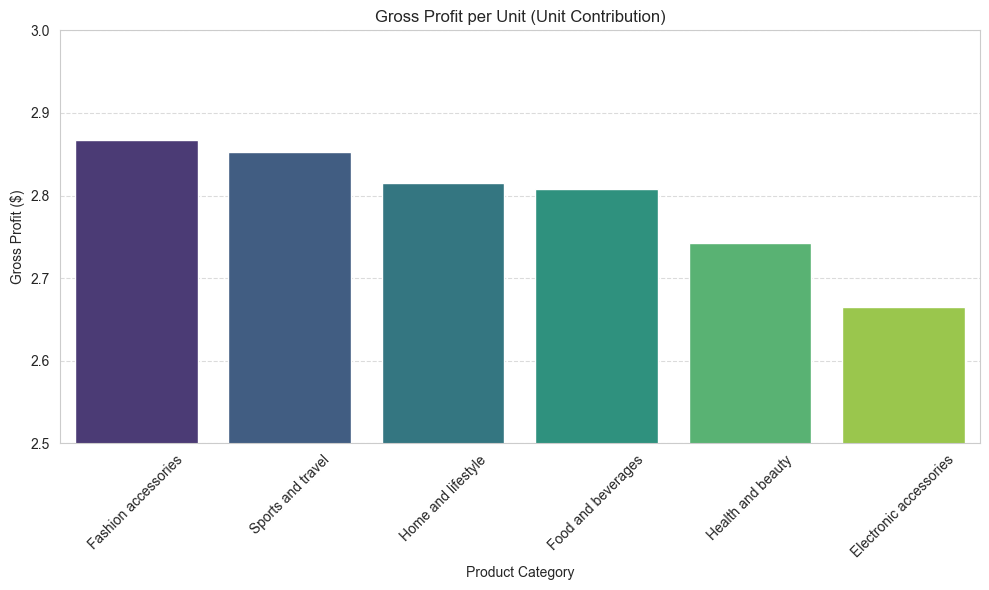

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Data Processing: Calculate Efficiency directly from main DataFrame
gross_profitunit = df.groupby('Product line')[['gross income', 'Quantity']].sum()

# 2. Feature Engineering: Create "Profit per Unit" Metric
gross_profitunit['Profit_per_Unit'] = gross_profitunit['gross income'] / gross_profitunit['Quantity']

# Sort results for better visualization
gross_profitunit = gross_profitunit.sort_values('Profit_per_Unit', ascending=False)

print("--- Gross Profit Analysis (Profit per Unit) ---")
print(gross_profitunit)

# 3. Visualization
plt.figure(figsize=(10, 6))

sns.barplot(
    x=gross_profitunit.index,
    y=gross_profitunit['Profit_per_Unit'],
    palette='viridis',
    hue=gross_profitunit.index,
    legend=False
)

# 4. Chart Styling
plt.title('Gross Profit per Unit (Unit Contribution)')
plt.ylabel('Gross Profit ($)') 
plt.xlabel('Product Category')
plt.xticks(rotation=45)

# to highlight the small differences (Micro-level analysis).
plt.ylim(2.5, 3.0) 
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_12644\3964437107.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


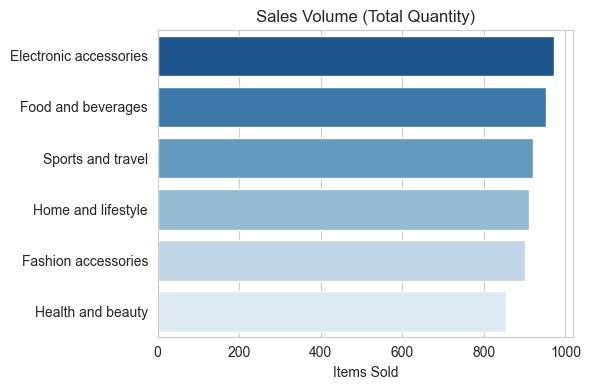

In [21]:
# Khusus untuk Slide 5 Bagian Kanan (Quantity Only)
# Kita urutkan berdasarkan Quantity biar rankingnya jelas
qty_chart = df.groupby('Product line')['Quantity'].sum().sort_values(ascending=False)

plt.figure(figsize=(6, 4)) # Ukuran compact

sns.barplot(
    x=qty_chart.values, 
    y=qty_chart.index, 
    palette='Blues_r' # Biru = Volume (dingin)
)

plt.title('Sales Volume (Total Quantity)', fontsize=12)
plt.xlabel('Items Sold')
plt.ylabel('') # Hilangkan label Y biar bersih
plt.tight_layout()

# Save dengan nama khusus
# export("Slide5_Right_Quantity.png") # Panggil fungsi save-mu
plt.show()

## 4. Conclusion & Recommendations

### 1. Key Findings
* **Unit Economics:** *Fashion Accessories* generate the highest profit per unit (~$2.86), while *Electronic Accessories* rely on high sales volume with the lowest profit per unit.
* **Peak Operations:** The busiest store traffic consistently occurs at **19:00 hours**.
* **Membership Inefficiency:** There is **no significant correlation** between Customer Type (Member vs. Normal) and Total Spending.

### 2. Hypothesis Conclusion
> **Hypothesis:** "Does the Membership program drive higher average spending?"
>
> **Verdict:** **REJECTED.**
> Data shows that Member and Normal customers have nearly identical spending distributions. The current membership program acts more like a label than a revenue driver.

### 3. Strategic Recommendations
Based on the data analysis, the following actions are recommended:

1.  **Product Bundling (Cross-Selling):**
    * Create bundles combining **High-Volume/Low-Margin items** (Electronics) with **High-Margin items** (Fashion) to maximize overall profitability per transaction.

2.  **Operational Optimization:**
    * Allocate maximum staff/cashiers during the **18:00 - 20:00** window to reduce wait times and improve Customer Rating.
    * Schedule inventory restocking during off-peak hours (morning) to avoid congestion.

3.  **Membership Revamp:**
    * Since spending is equal, introduce a **Tiered Reward System** or **Gamification** to incentivize Members to increase their basket size.